# Customer Churn: Exploratory Data Analysis (EDA)

This notebook is part of the Telco Customer Churn machine learning project that is uusing the IBM dataset. 

**EDA** phase is important for understanding and determinig the patterns and properties of the dataset. 
This phase has a huge importance in trying to understand the data and the relations between the variables.

In [20]:
import pandas as pd
from data_preprocessing import print_basic_info, clean_preprocess_data
from plot_utils import (
    plot_tenure_distribution,
    plot_senior_citizens_pie,
    plot_churn_by_gender,
    plot_partners_pie,
    plot_contract_type_bar,
    plot_contract_type_pie,
    plot_correlation_heatmap,
    plot_churn_by_contract_type,
    plot_target_distribution
)

## Initial Data Exploration

In [21]:
df = pd.read_csv('../data/raw/telco-customer-churn-ibm.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### There are duplicate rows and some missing values that will need to be be cleaned. I have also identified customerID column which is not required for our churn analysis. This column will be removed.
I will also convert **MonthlyCharges** to a numeric value behind the scene. This seems to be the only column that is supposed to be a numerical value

In [22]:
clean_preprocess_data(df)

[INFO] Missing values before: 11
[INFO] Duplicate rows before: 22
[INFO] Missing values after: 0
[INFO] Duplicate rows after: 0
[INFO] Final dataset shape: (7010, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [23]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7010.000000,7010.000000,7010.000000,7010.000000
mean,0.162767,32.520399,64.888666,2290.353388
std,0.369180,24.520441,30.064769,2266.820832
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.750000,408.312500
50%,0.000000,29.000000,70.400000,1403.875000
75%,0.000000,56.000000,89.900000,3807.837500
max,1.000000,72.000000,118.750000,8684.800000


### Distribution of Target Variable (Churn)
- This distribution is not balanced, therefore, I will need to balance the data with SMOTE technique to ensure balanced classes before I begin with feature engineering and model training.

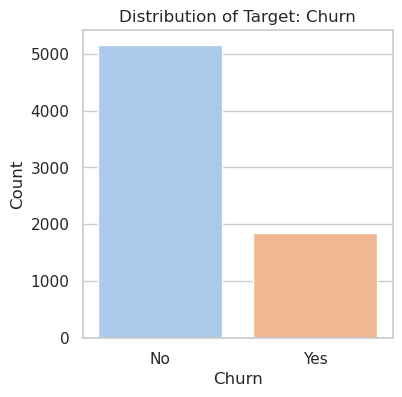

In [24]:
plot_target_distribution(df, target_col='Churn')

### Senior Citizens in the Dataset
- Most of the customers aare not senior citizens. Therefore, I do not expect churn to be influenced by this variable.

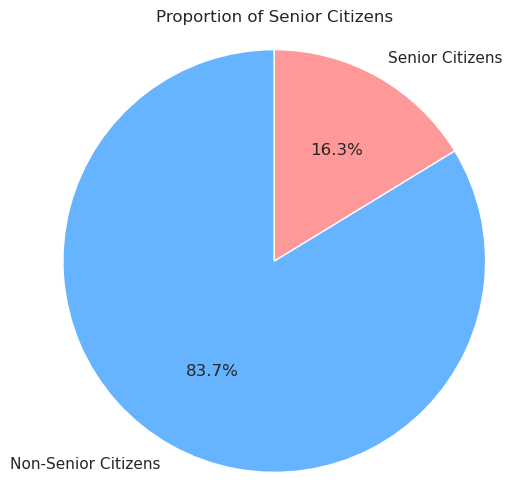

In [25]:
plot_senior_citizens_pie(df)

### Churn by Gender
- The churn between male and female customers is almost the same, which is valuable information

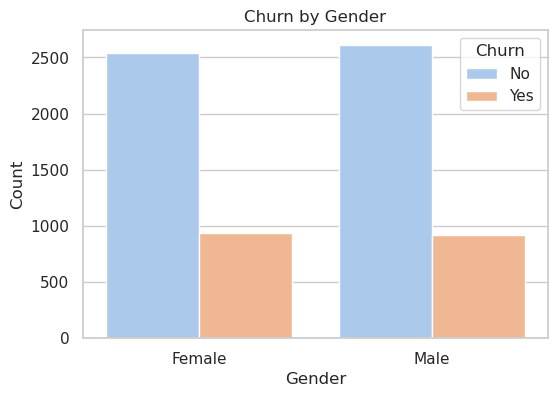

In [26]:
plot_churn_by_gender(df)

### Customers With and Without Partners

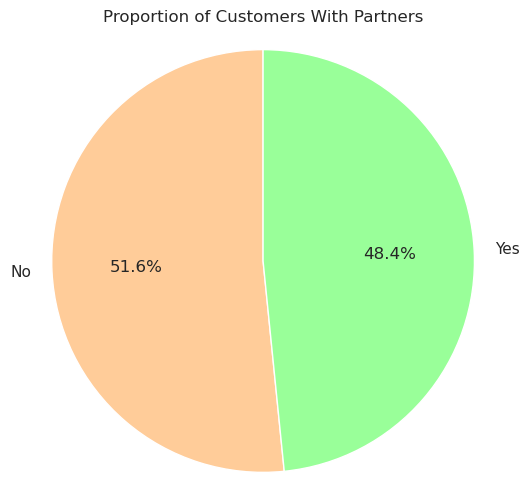

In [27]:
plot_partners_pie(df)

### Customers by Contract Type
- More than 50% of customers are on Month-to-Month contract
- These 3 variables will be interesting to see if any of them have a high churn rate

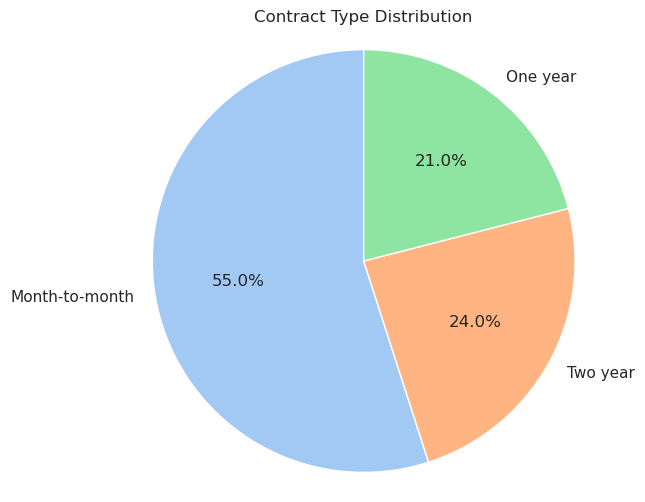

In [28]:
plot_contract_type_pie(df)

### Churn by Contract Type
- It is clear based on the below data that most churners are on Month-to-month contract type.
- I will need to evaluate charges for each contract type.
- Could it be Month-to-month is high?
- what are the insentives of being on other contract types that are not on Month-to-month?

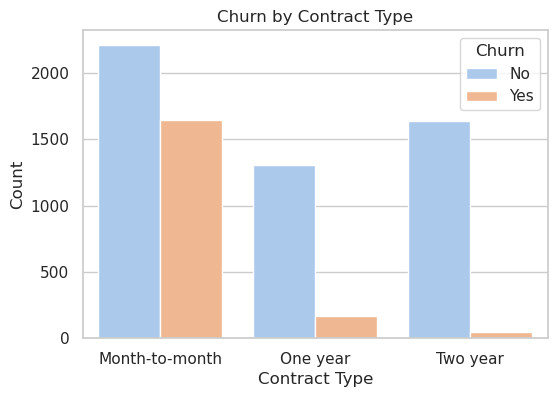

In [29]:
plot_churn_by_contract_type(df)

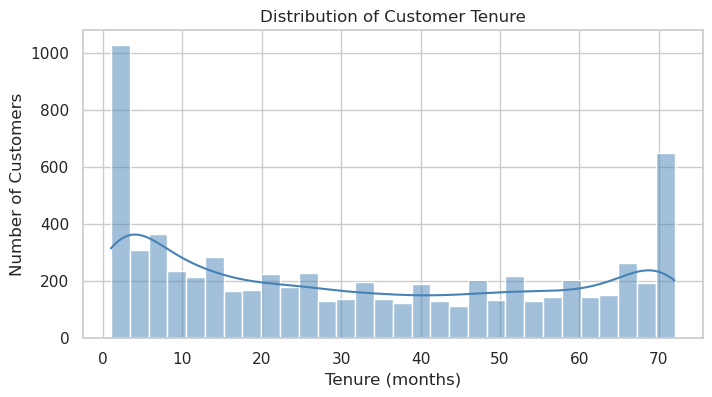

In [30]:
plot_tenure_distribution(df)

### Correlation Heatmap

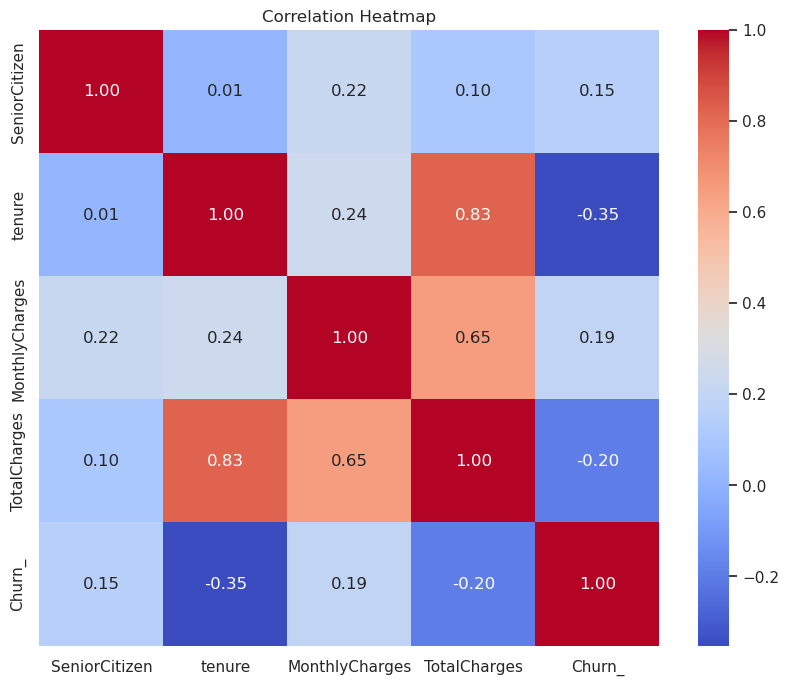

In [31]:
df['Churn_'] = df['Churn'].map({'No': 0, 'Yes': 1})
plot_correlation_heatmap(df)

## Summary
- Customers on flexible (month-to-month) contracts are at higher risk of churn
- I will perform statistical analysis to better understand the dataset

### NB: This is first eda of an iterative process, more insights will be discovered in statistical analysis.